In [5]:
import pandas as pd

df = pd.read_csv("placement_dataset_large.csv")
df.head()

,age,gender,cgpa,branch,internships,projects,technical_skills_score,aptitude_score,communication_skills,certifications,workshops,backlogs
0,23,Male,9.23,CSE,1,4,6.0,64.0,5.0,1.0,0.0,0.0
1,24,Female,7.92,IT,1,5,9.0,53.0,8.0,1.0,2.0,3.0
2,22,Male,6.53,Civil,0,5,7.0,70.0,4.0,3.0,1.0,1.0
3,24,Male,8.42,ECE,0,3,8.0,62.0,6.0,3.0,1.0,1.0
4,24,Female,8.68,Mechanical,0,5,8.0,71.0,4.0,0.0,2.0,2.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     300 non-null    int64  
 1   gender                  300 non-null    object 
 2   cgpa                    300 non-null    float64
 3   branch                  300 non-null    object 
 4   internships             300 non-null    int64  
 5   projects                300 non-null    int64  
 6   technical_skills_score  298 non-null    float64
 7   aptitude_score          297 non-null    float64
 8   communication_skills    298 non-null    float64
 9   certifications          298 non-null    float64
 10  workshops               298 non-null    float64
 11  backlogs                299 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 28.3+ KB


In [7]:
df.describe()

,age,cgpa,internships,projects,technical_skills_score,aptitude_score,communication_skills,certifications,workshops,backlogs
count,300.000000,300.000000,300.000000,300.000000,298.000000,297.000000,298.000000,298.000000,298.000000,299.000000
mean,21.953333,7.683167,1.403333,2.973333,6.496644,71.154882,6.567114,1.506711,1.030201,1.438127
std,1.401560,1.225712,1.103653,1.406847,1.702144,13.057419,1.690892,1.128878,0.826188,1.134578
min,20.000000,5.510000,0.000000,1.000000,4.000000,50.000000,4.000000,0.000000,0.000000,0.000000
25%,21.000000,6.635000,0.000000,2.000000,5.000000,60.000000,5.000000,1.000000,0.000000,0.000000
50%,22.000000,7.735000,1.000000,3.000000,7.000000,71.000000,7.000000,1.000000,1.000000,1.000000
75%,23.000000,8.692500,2.000000,4.000000,8.000000,83.000000,8.000000,3.000000,2.000000,2.000000
max,24.000000,9.790000,3.000000,5.000000,9.000000,94.000000,9.000000,3.000000,2.000000,3.000000


In [8]:
df.isnull().sum()

,0
age,0
gender,0
cgpa,0
branch,0
internships,0
projects,0
technical_skills_score,2
aptitude_score,3
communication_skills,2
certifications,2


In [11]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [12]:
df.isnull().sum()

,0
age,0
gender,0
cgpa,0
branch,0
internships,0
projects,0
technical_skills_score,0
aptitude_score,0
communication_skills,0
certifications,0


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='aptitude_score', ylabel='Count'>

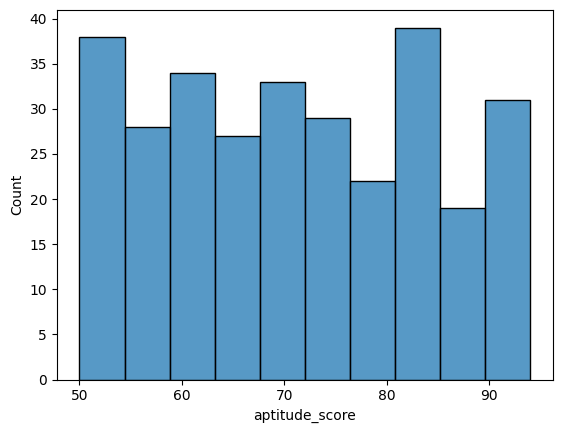

In [14]:
sns.histplot(df['aptitude_score'])

In [18]:
df['placed'] = (
    (df['cgpa'] > 7).astype(int) +
    (df['internships'] > 0).astype(int) +
    (df['technical_skills_score'] > 6).astype(int) +
    (df['aptitude_score'] > 70).astype(int) -
    (df['backlogs'] > 1).astype(int)
)

df['placed'] = (df['placed'] >= 3).astype(int)

In [19]:
df['placed'].value_counts()

,count
placed,
0,207
1,93


In [20]:
df['placed'].value_counts()

,count
placed,
0,207
1,93


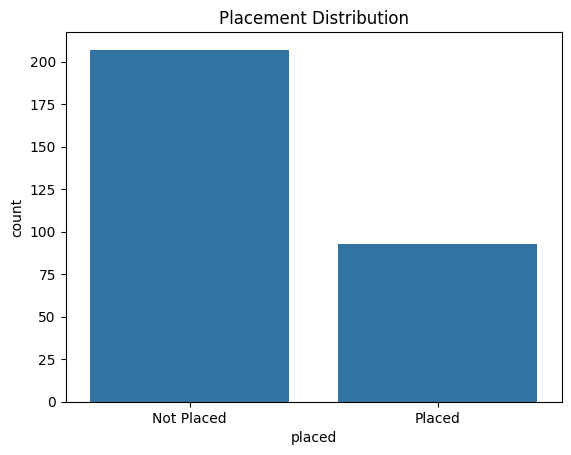

In [22]:
sns.countplot(x='placed', data=df)
plt.title("Placement Distribution")

plt.xticks([0, 1], ["Not Placed", "Placed"])

plt.show()

A significantly higher number of students are not placed compared to those placed.

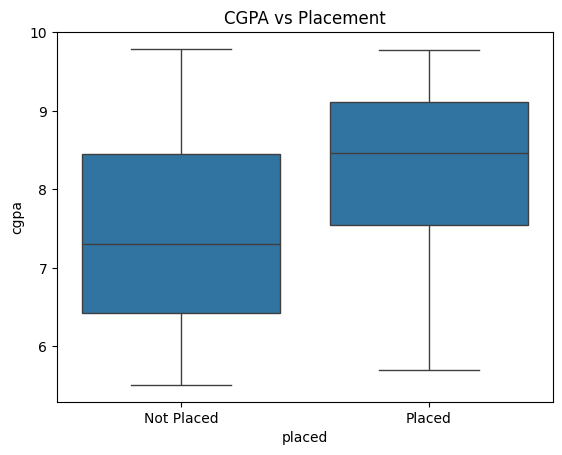

In [25]:
sns.boxplot(x='placed', y='cgpa', data=df)
plt.title("CGPA vs Placement")
plt.xticks([0, 1], ["Not Placed", "Placed"])
plt.show()

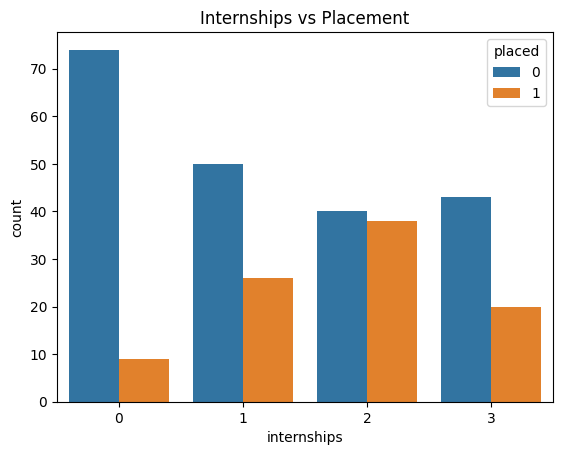

In [26]:
sns.countplot(x='internships', hue='placed', data=df)
plt.title("Internships vs Placement")
plt.show()

“Students with internships have a significantly higher chance of being placed. The probability of placement increases as the number of internships increases, especially up to 2 internships.”

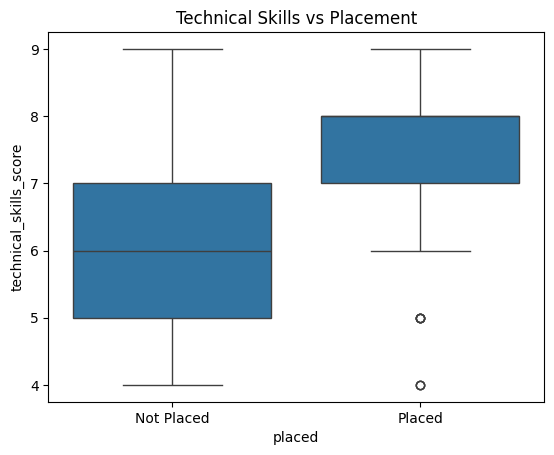

In [28]:
sns.boxplot(x='placed', y='technical_skills_score', data=df)
plt.title("Technical Skills vs Placement")
plt.xticks([0, 1], ["Not Placed", "Placed"])
plt.show()

In [30]:
df['backlogs'] = df['backlogs'].round().astype(int)

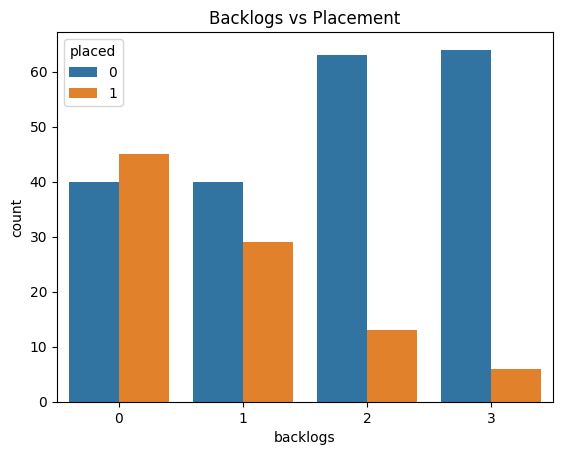

In [31]:
sns.countplot(x='backlogs', hue='placed', data=df)
plt.title("Backlogs vs Placement")
plt.show()

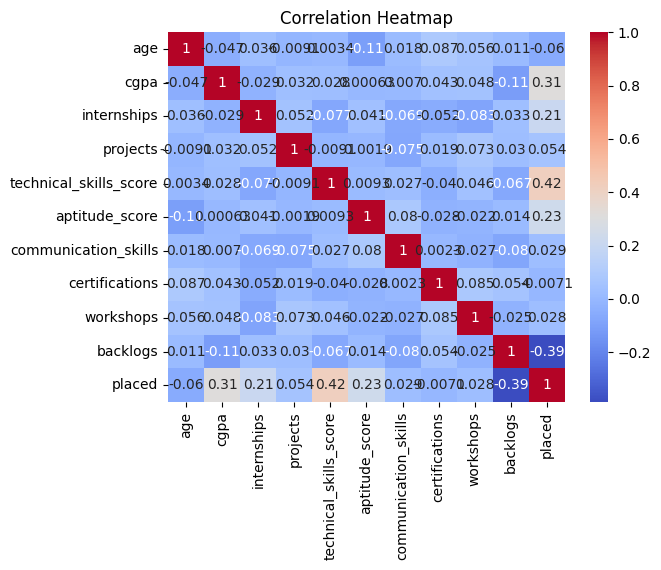

In [32]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [33]:
X = df.drop('placed', axis=1)
y = df['placed']

In [34]:
X = pd.get_dummies(X, drop_first=True)

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [37]:
y_pred = model.predict(X_test)

In [38]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.75
              precision    recall  f1-score   support

           0       0.79      0.81      0.80        37
           1       0.68      0.65      0.67        23

    accuracy                           0.75        60
   macro avg       0.74      0.73      0.73        60
weighted avg       0.75      0.75      0.75        60



In [39]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

RF Accuracy: 0.8166666666666667


In [40]:
input_data = [[
    22,        # age
    8.2,       # cgpa
    2,         # internships
    3,         # projects
    8,         # technical skills
    85,        # aptitude
    7,         # communication
    2,         # certifications
    1,         # workshops
    0          # backlogs
]]

In [41]:
input_df = pd.DataFrame(input_data, columns=[
    'age', 'cgpa', 'internships', 'projects',
    'technical_skills_score', 'aptitude_score',
    'communication_skills', 'certifications',
    'workshops', 'backlogs'
])

In [42]:
input_df = pd.get_dummies(input_df)

input_df = input_df.reindex(columns=X.columns, fill_value=0)

In [43]:
prediction = model.predict(input_df)

if prediction[0] == 1:
    print("✅ Student will be Placed")
else:
    print("❌ Student will NOT be Placed")

✅ Student will be Placed


In [44]:
input_data = [[
    23,     # age
    6.2,    # cgpa (low)
    0,      # internships (none)
    1,      # projects (very few)
    4,      # technical skills (low)
    55,     # aptitude (low)
    5,      # communication (average-low)
    0,      # certifications
    0,      # workshops
    3       # backlogs (high ❌)
]]

In [45]:
input_df = pd.DataFrame(input_data, columns=[
    'age', 'cgpa', 'internships', 'projects',
    'technical_skills_score', 'aptitude_score',
    'communication_skills', 'certifications',
    'workshops', 'backlogs'
])

input_df = pd.get_dummies(input_df)
input_df = input_df.reindex(columns=X.columns, fill_value=0)

prediction = model.predict(input_df)

print("Prediction:", "Placed ✅" if prediction[0]==1 else "Not Placed ❌")

Prediction: Not Placed ❌
